# LDA

### Computation

=== LDA Dataset Log ===
Dataset shape: (1000, 4)
Class distribution: Class 0 (Hold/Sell): 733, Class 1 (Buy): 267
Feature names: ['RSI', 'MACD', 'Volume', 'Price']

=== Split Log ===
Train shape: (800, 4), Test shape: (200, 4)
Train class dist: Class 0: 589, Class 1: 211

=== LDA Model Results Log ===
Accuracy on test set: 0.8950
Sample predictions for the first 5 test samples: [0 0 0 1 0]
Confusion Matrix (rows: true, cols: pred):
 [[138   6]
 [ 15  41]]
LDA coefficients (discriminant weights):
RSI: 1.9547
MACD: 2.0010
Volume: -0.0901
Price: 0.0565


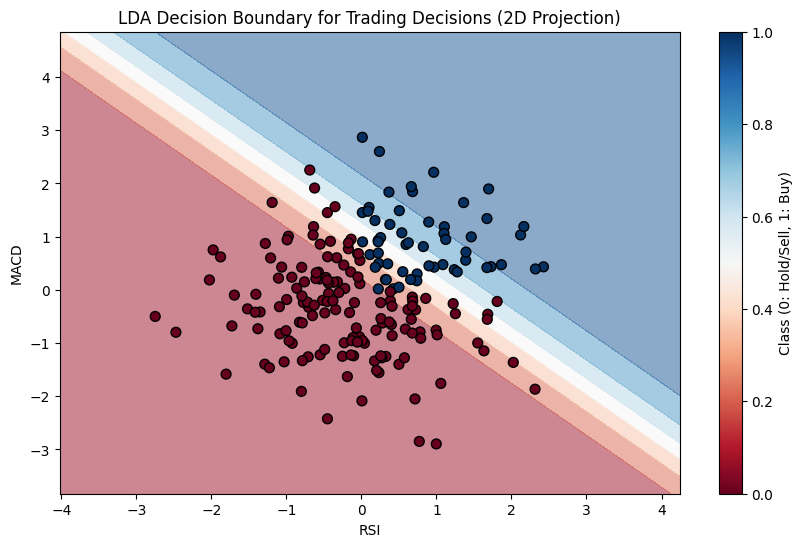


=== Plot Log ===
Plot generated: Scatter of test points (blue: class 0, red: class 1) on 2D RSI-MACD plane.
Linear decision boundary (shaded RdBu regions for probabilities) separates classes diagonally.
Image saved as: MLFinance/images/lda_illustration.png
=== End of LDA Logs ===


In [3]:
# Refactored LDA Code: Computation, Logs, and Illustration in One Block
# Run this entire block in your Jupyter notebook cell.
# Ensure 'MLFinance/images/' directory exists (mkdir -p MLFinance/images)

import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay  # For boundary plot (sklearn >=1.0)

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 4 features (e.g., RSI, MACD, volume, price)
n_samples = 1000
X = np.random.randn(n_samples, 4)  # Features
y = (X[:, 0] > 0) & (X[:, 1] > 0)  # Simple rule: buy if RSI and MACD positive, else hold/sell
y = np.where(y, 1, 0)  # Binary classification: 1 (buy), 0 (hold/sell)
feature_names = ["RSI", "MACD", "Volume", "Price"]

# Log: Dataset summary
print("=== LDA Dataset Log ===")
print(f"Dataset shape: {X.shape}")
print(f"Class distribution: Class 0 (Hold/Sell): {np.sum(y==0)}, Class 1 (Buy): {np.sum(y==1)}")
print(f"Feature names: {feature_names}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Log: Train/Test split
print("\n=== Split Log ===")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class dist: Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)}")

# Apply LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict and evaluate
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Log: Model results
print("\n=== LDA Model Results Log ===")
print(f"Accuracy on test set: {accuracy:.4f}")
print("Sample predictions for the first 5 test samples:", y_pred[:5])
print("Confusion Matrix (rows: true, cols: pred):\n", cm)
print("LDA coefficients (discriminant weights):")
for name, coef in zip(feature_names, lda.coef_[0]):
    print(f"{name}: {coef:.4f}")

# Illustration: 2D projection (first two features: RSI, MACD) with decision boundary
X2_train = X_train[:, :2]
X2_test = X_test[:, :2]

lda2 = LinearDiscriminantAnalysis()
lda2.fit(X2_train, y_train)

# Plot decision boundary and test points
fig, ax = plt.subplots(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    lda2, X2_train, cmap='RdBu', alpha=0.5, ax=ax, response_method='predict_proba'
)
scatter = ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y_test, cmap='RdBu', edgecolors='k', s=50)
ax.set_xlabel("RSI")
ax.set_ylabel("MACD")
ax.set_title("LDA Decision Boundary for Trading Decisions (2D Projection)")
plt.colorbar(scatter, ax=ax, label='Class (0: Hold/Sell, 1: Buy)')
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/lda_illustration.png', dpi=300, bbox_inches='tight')
plt.show()

# Log: Plot summary (for report reference)
print("\n=== Plot Log ===")
print("Plot generated: Scatter of test points (blue: class 0, red: class 1) on 2D RSI-MACD plane.")
print("Linear decision boundary (shaded RdBu regions for probabilities) separates classes diagonally.")
print("Image saved as: MLFinance/images/lda_illustration.png")
print("=== End of LDA Logs ===")

# SVM

=== SVM Dataset Log ===
Dataset shape: (1000, 4)
Class distribution: Class 0 (Hold/Sell): 733, Class 1 (Buy): 267
Feature names: ['RSI', 'MACD', 'Volume', 'Price']

=== Split Log ===
Train shape: (800, 4), Test shape: (200, 4)
Train class dist: Class 0: 589, Class 1: 211

=== SVM Model Results Log ===
Accuracy on test set: 0.9850
Sample predictions for the first 5 test samples: [0 0 0 0 0]
Confusion Matrix (rows: true, cols: pred):
 [[143   1]
 [  2  54]]
Number of support vectors: [97 94]


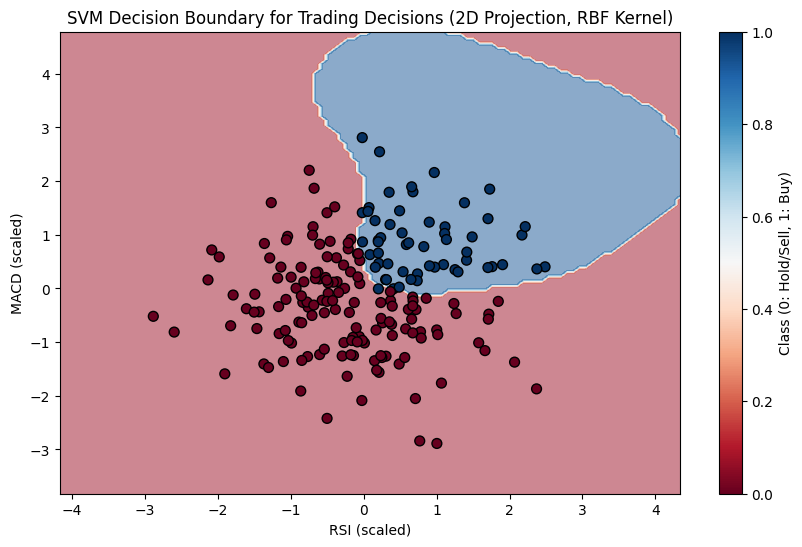


=== Plot Log ===
Plot generated: Scatter of test points (blue: class 0, red: class 1) on 2D scaled RSI-MACD plane.
Non-linear decision boundary (shaded RdBu regions) curves to separate classes.
Image saved as: /Users/alberto/Documents/projects/GWP_1/MLFinance/images/svm_illustration.png
=== End of SVM Logs ===


In [4]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay  # For boundary plot (sklearn >=1.0)

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 4 features (e.g., RSI, MACD, volume, price)
n_samples = 1000
X = np.random.randn(n_samples, 4)  # Features
y = (X[:, 0] > 0) & (X[:, 1] > 0)  # Simple rule: buy if RSI and MACD positive, else hold/sell
y = np.where(y, 1, 0)  # Binary classification: 1 (buy), 0 (hold/sell)
feature_names = ["RSI", "MACD", "Volume", "Price"]

# Standardize features (SVM requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Log: Dataset summary
print("=== SVM Dataset Log ===")
print(f"Dataset shape: {X_scaled.shape}")
print(f"Class distribution: Class 0 (Hold/Sell): {np.sum(y==0)}, Class 1 (Buy): {np.sum(y==1)}")
print(f"Feature names: {feature_names}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Log: Train/Test split
print("\n=== Split Log ===")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class dist: Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)}")

# Apply SVM model (RBF kernel for non-linearity)
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Log: Model results
print("\n=== SVM Model Results Log ===")
print(f"Accuracy on test set: {accuracy:.4f}")
print("Sample predictions for the first 5 test samples:", y_pred[:5])
print("Confusion Matrix (rows: true, cols: pred):\n", cm)
print("Number of support vectors:", svm.n_support_)

# Illustration: 2D projection (first two features: RSI, MACD) with decision boundary
X2_train = X_train[:, :2]
X2_test = X_test[:, :2]

svm2 = SVC(kernel='rbf', C=1.0, random_state=42)
svm2.fit(X2_train, y_train)

# Plot decision boundary and test points
fig, ax = plt.subplots(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    svm2, X2_train, cmap='RdBu', alpha=0.5, ax=ax, response_method='predict'
)
scatter = ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y_test, cmap='RdBu', edgecolors='k', s=50)
ax.set_xlabel("RSI (scaled)")
ax.set_ylabel("MACD (scaled)")
ax.set_title("SVM Decision Boundary for Trading Decisions (2D Projection, RBF Kernel)")
plt.colorbar(scatter, ax=ax, label='Class (0: Hold/Sell, 1: Buy)')
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/svm_illustration.png', dpi=300, bbox_inches='tight')
plt.show()

# Log: Plot summary (for report reference)
print("\n=== Plot Log ===")
print("Plot generated: Scatter of test points (blue: class 0, red: class 1) on 2D scaled RSI-MACD plane.")
print("Non-linear decision boundary (shaded RdBu regions) curves to separate classes.")
print("Image saved as: /Users/alberto/Documents/projects/GWP_1/MLFinance/images/svm_illustration.png")
print("=== End of SVM Logs ===")

# NN

=== NN Dataset Log ===
Dataset shape: (1000, 4)
Class distribution: Class 0 (Hold/Sell): 733, Class 1 (Buy): 267
Feature names: ['RSI', 'MACD', 'Volume', 'Price']

=== Split Log ===
Train shape: (800, 4), Test shape: (200, 4)
Train class dist: Class 0: 589, Class 1: 211

=== NN Model Results Log ===
Accuracy on test set: 0.9900
Sample predictions for the first 5 test samples: [0 0 0 0 0]
Confusion Matrix (rows: true, cols: pred):
 [[144   0]
 [  2  54]]
Number of hidden units: 100
Loss curve summary: Converged after 474 iterations


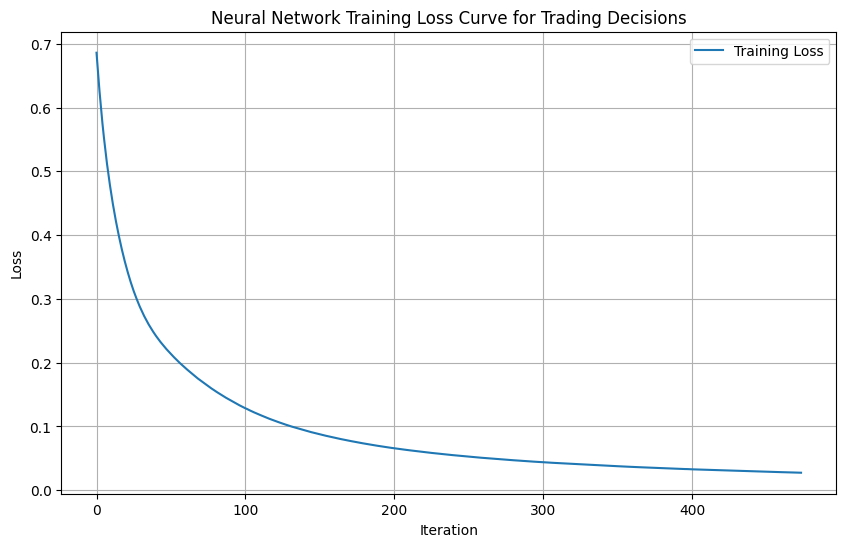


=== Plot Log ===
Plot generated: Line plot of training loss decreasing over iterations.
Shows convergence of the NN model on the financial dataset.
Image saved as: /Users/alberto/Documents/projects/GWP_1/MLFinance/images/nn_illustration.png
=== End of NN Logs ===


In [5]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 4 features (e.g., RSI, MACD, volume, price)
n_samples = 1000
X = np.random.randn(n_samples, 4)  # Features
y = (X[:, 0] > 0) & (X[:, 1] > 0)  # Simple rule: buy if RSI and MACD positive, else hold/sell
y = np.where(y, 1, 0)  # Binary classification: 1 (buy), 0 (hold/sell)
feature_names = ["RSI", "MACD", "Volume", "Price"]

# Standardize features (NN benefits from scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Log: Dataset summary
print("=== NN Dataset Log ===")
print(f"Dataset shape: {X_scaled.shape}")
print(f"Class distribution: Class 0 (Hold/Sell): {np.sum(y==0)}, Class 1 (Buy): {np.sum(y==1)}")
print(f"Feature names: {feature_names}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Log: Train/Test split
print("\n=== Split Log ===")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class dist: Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)}")

# Apply NN model (simple MLP with one hidden layer)
nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, verbose=False)
nn.fit(X_train, y_train)

# Predict and evaluate
y_pred = nn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Log: Model results
print("\n=== NN Model Results Log ===")
print(f"Accuracy on test set: {accuracy:.4f}")
print("Sample predictions for the first 5 test samples:", y_pred[:5])
print("Confusion Matrix (rows: true, cols: pred):\n", cm)
print(f"Number of hidden units: 100")
print("Loss curve summary: Converged after", nn.n_iter_, "iterations")

# Illustration: Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(nn.loss_curve_, label='Training Loss')
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Neural Network Training Loss Curve for Trading Decisions")
ax.legend()
ax.grid(True)
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/nn_illustration.png', dpi=300, bbox_inches='tight')
plt.show()

# Log: Plot summary (for report reference)
print("\n=== Plot Log ===")
print("Plot generated: Line plot of training loss decreasing over iterations.")
print("Shows convergence of the NN model on the financial dataset.")
print("Image saved as: /Users/alberto/Documents/projects/GWP_1/MLFinance/images/nn_illustration.png")
print("=== End of NN Logs ===")